In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
from differentiable_lensing import DifferentiableLensing, shared_colorimshow
import data
from sisr import SISR

In [3]:
magnification = 2
n_mag = 1
residual_depth = 3
in_channels = 2
latent_space_size = 64
device = 'cuda' if torch.cuda.is_available() else 'cpu'
target_resolution = 0.101/2
target_shape = 128

In [4]:
BATCH_SIZE = 1 # Feel free to increase this number; all the training was done on my personal machine, hence, this limitation

val_dataset_no_sub = data.LensingDataset('val/',['no_sub'],2000)
val_dataset_axion = data.LensingDataset('val/',['axion'],2000)
val_dataset_cdm = data.LensingDataset('val/',['cdm'],2000)

model = SISR(magnification=magnification, n_mag=n_mag, residual_depth=residual_depth, in_channels=in_channels, latent_channel_count=latent_space_size).to(device)
model.load_state_dict(torch.load('sis_stage3_checkpoint.pt'))
lensing_module = DifferentiableLensing(device=device, alpha=None, target_resolution=target_resolution, target_shape=target_shape).to(device)

cross_grid_to_log = torch.load('scatter_to_log_128.pt').to(device)
cross_grid_forward_from_log = torch.load('forward_from_log_128.pt').to(device)
cross_grid_from_log = torch.load('scatter_from_log_128.pt').to(device)
cross_grid_backward = torch.load('sparse_grid_fracs_euclid_backward.pt').to(device)

psf, _, _ = lensing_module.gaussian_kernel(fwhm_arcsec=0.16, pixscale_arcsec=target_resolution)
psf = torch.tensor(psf, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0).to(device)

C:\Users\upraj\AppData\Local\Temp\ipykernel_24000\2150113041.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('sis_stage3_checkpoint.pt')

RuntimeError: Error(s) in loading state_dict for SISR:
	Missing key(s) in state_dict: "residual_layer_list.0.0.weight", "residual_layer_list.0.0.bias", "residual_layer_list.0.1.weight", "residual_layer_list.0.1.bias", "residual_layer_list.0.1.running_mean", "residual_layer_list.0.1.running_var", "residual_layer_list.0.3.weight", "residual_layer_list.0.3.bias", "residual_layer_list.0.4.weight", "residual_layer_list.0.4.bias", "residual_layer_list.0.4.running_mean", "residual_layer_list.0.4.running_var", "residual_layer_list.1.0.weight", "residual_layer_list.1.0.bias", "residual_layer_list.1.1.weight", "residual_layer_list.1.1.bias", "residual_layer_list.1.1.running_mean", "residual_layer_list.1.1.running_var", "residual_layer_list.1.3.weight", "residual_layer_list.1.3.bias", "residual_layer_list.1.4.weight", "residual_layer_list.1.4.bias", "residual_layer_list.1.4.running_mean", "residual_layer_list.1.4.running_var", "residual_layer_list.2.0.weight", "residual_layer_list.2.0.bias", "res

In [ ]:
def test_complete(dataset, image_indices):
    images_for_plot = []
    for index in image_indices:
        lr_image = dataset[index].unsqueeze(0).float().to(device)

        # Source reconstruction through backward lensing
        reconstructed_source = lensing_module.cross_grid_fill(lr_image, [cross_grid_backward]) # rename to lensing

        # Upscaling using a neural network
        model_feed = torch.cat([reconstructed_source, lr_image], dim=1)
        with torch.no_grad():
            upscaled_source_ = model(model_feed)

        # Image construction through forward lensing
        upscaled_image_ = lensing_module.cross_grid_fill(upscaled_source_, [cross_grid_to_log, cross_grid_forward_from_log, cross_grid_from_log])
        convolved_upscaled_image_ = F.conv2d(upscaled_image_, psf, padding="same")
        images_for_plot.append(lr_image[0,0].cpu())
        images_for_plot.append(reconstructed_source[0,0].cpu())
        images_for_plot.append(upscaled_source_[0,0].cpu())
        images_for_plot.append(upscaled_image_[0,0].cpu())
        images_for_plot.append(convolved_upscaled_image_[0,0].cpu())
    return shared_colorimshow(images_for_plot, nrows=len(image_indices), ncols=5, cmap='grey')

def test_images(dataset, image_indices):
    images_for_plot = []
    for index in image_indices:
        lr_image = dataset[index].unsqueeze(0).float().to(device)

        # Source reconstruction through backward lensing
        reconstructed_source = lensing_module.cross_grid_fill(lr_image, [cross_grid_backward]) # rename to lensing

        # Upscaling using a neural network
        model_feed = torch.cat([reconstructed_source, lr_image], dim=1)
        with torch.no_grad():
            upscaled_source_ = model(model_feed)

        # Image construction through forward lensing
        upscaled_image_ = lensing_module.cross_grid_fill(upscaled_source_, [cross_grid_to_log, cross_grid_forward_from_log, cross_grid_from_log])
        convolved_upscaled_image_ = F.conv2d(upscaled_image_, psf, padding="same")
        images_for_plot.append(lr_image[0,0].cpu())
        images_for_plot.append(upscaled_image_[0,0].cpu())
        images_for_plot.append(convolved_upscaled_image_[0,0].cpu())
    return shared_colorimshow(images_for_plot, nrows=len(image_indices), ncols=3, cmap='grey')

def test_inout(dataset, image_indices):
    images_for_plot = []
    titles = []
    for index in image_indices:
        lr_image = dataset[index].unsqueeze(0).float().to(device)

        # Source reconstruction through backward lensing
        reconstructed_source = lensing_module.cross_grid_fill(lr_image, [cross_grid_backward]) # rename to lensing

        # Upscaling using a neural network
        model_feed = torch.cat([reconstructed_source, lr_image], dim=1)
        with torch.no_grad():
            upscaled_source_ = model(model_feed)

        # Image construction through forward lensing
        upscaled_image_ = lensing_module.cross_grid_fill(upscaled_source_, [cross_grid_to_log, cross_grid_forward_from_log, cross_grid_from_log])
        convolved_upscaled_image_ = F.conv2d(upscaled_image_, psf, padding="same")
        images_for_plot.append(lr_image[0,0].cpu())
        images_for_plot.append(convolved_upscaled_image_[0,0].cpu())
        titles.append('LR observed image')
        titles.append('SR approximation')
    return shared_colorimshow(images_for_plot, nrows=len(image_indices), ncols=2, cmap='grey', set_title=titles)

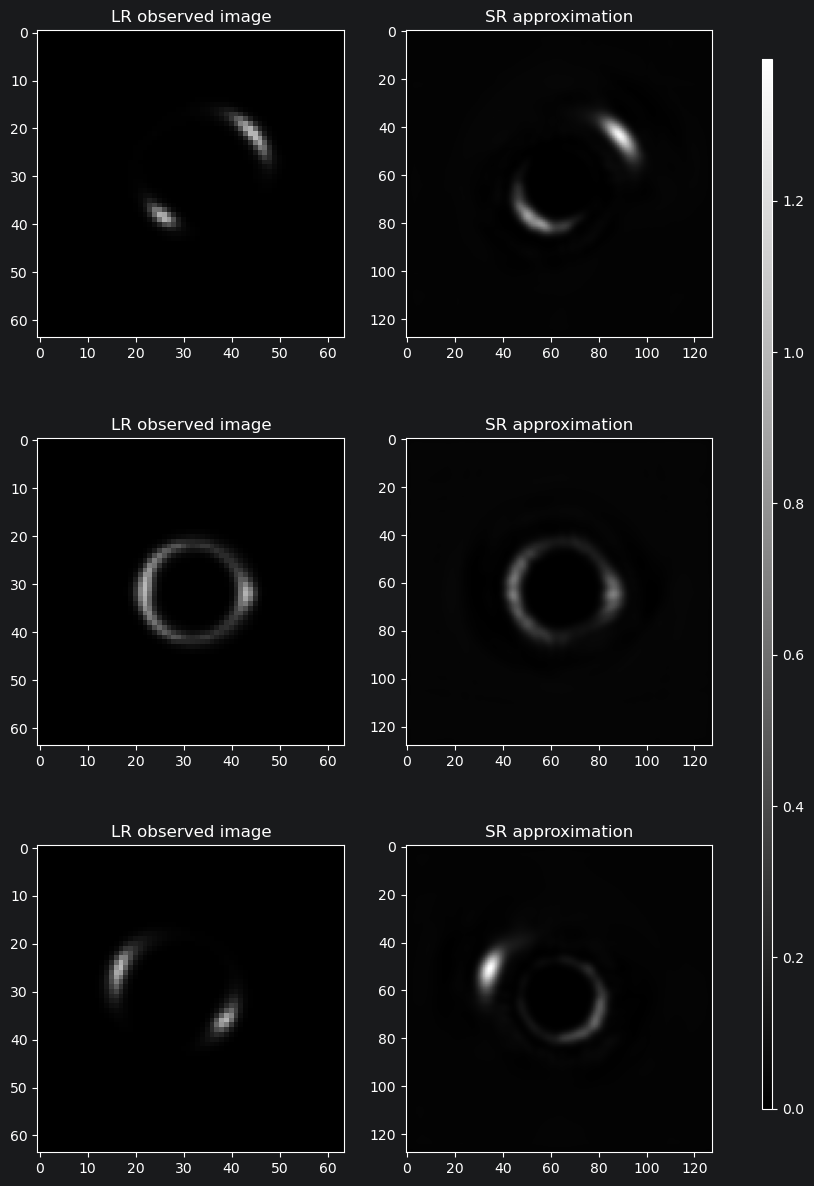

In [6]:
plot, axes = test_inout(val_dataset_no_sub, [4,5,6])
plot.savefig('first_results.pdf')